#📌 Extracción

In [ ]:
import pandas as pd
import json


file_path = 'TelecomX_Data.json'

def cargar_datos_locales(ruta):
    try:
        # Abrimos el archivo local
        with open(ruta, 'r', encoding='utf-8') as f:
            datos = json.load(f)

        # Convertimos a DataFrame

        df = pd.DataFrame(datos)

        print(" Datos cargados correctamente desde el archivo local.")
        print(f"Dimensiones: {df.shape[0]} filas y {df.shape[1]} columnas.")
        return df

    except FileNotFoundError:
        print(f" Error: El archivo '{ruta}' no se encuentra en el entorno actual.")
        return None
    except Exception as e:
        print(f" Ocurrió un error inesperado: {e}")
        return None

# Ejecución
df_telecom = cargar_datos_locales(file_path)

# Verificación inicial de la estructura de Telecom X
if df_telecom is not None:
    display(df_telecom.head())
    print("\nTipos de datos detectados:")
    print(df_telecom.info())

✅ Datos cargados correctamente desde el archivo local.
Dimensiones: 7267 filas y 6 columnas.


,customerID,Churn,customer,phone,internet,account
0,0002-ORFBO,No,"{'gender': 'Female', 'SeniorCitizen': 0, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'One year', 'PaperlessBilling': '..."
1,0003-MKNFE,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'Yes'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
2,0004-TLHLJ,Yes,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
3,0011-IGKFF,Yes,"{'gender': 'Male', 'SeniorCitizen': 1, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
4,0013-EXCHZ,Yes,"{'gender': 'Female', 'SeniorCitizen': 1, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."



Tipos de datos detectados:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   customerID  7267 non-null   object
 1   Churn       7267 non-null   object
 2   customer    7267 non-null   object
 3   phone       7267 non-null   object
 4   internet    7267 non-null   object
 5   account     7267 non-null   object
dtypes: object(6)
memory usage: 340.8+ KB
None


#🔧 Transformación

In [ ]:
import pandas as pd

# Cargar los datos
# df_telecom = pd.read_json('TelecomX_Data.json')

if 'df_telecom' in locals():
    # 1. Exploración de tipos de datos y valores nulos
    print("### ESTRUCTURA TÉCNICA DEL DATASET ###")
    print(df_telecom.info())

    # 2. Resumen estadístico inicial
    print("\n### RESUMEN ESTADÍSTICO ###")
    display(df_telecom.describe(include='all').T)

    # 3. Verificación de la variable objetivo (Churn)
    print("\n### DISTRIBUCIÓN DE LA EVASIÓN (CHURN) ###")
    print(df_telecom['Churn'].value_counts(normalize=True) * 100)
else:
    print("Por favor, asegúrate de haber cargado el DataFrame 'df_telecom' primero.")

### ESTRUCTURA TÉCNICA DEL DATASET ###
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   customerID  7267 non-null   object
 1   Churn       7267 non-null   object
 2   customer    7267 non-null   object
 3   phone       7267 non-null   object
 4   internet    7267 non-null   object
 5   account     7267 non-null   object
dtypes: object(6)
memory usage: 340.8+ KB
None

### RESUMEN ESTADÍSTICO ###


,count,unique,top,freq
customerID,7267,7267,9995-HOTOH,1
Churn,7267,3,No,5174
customer,7267,891,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...",223
phone,7267,3,"{'PhoneService': 'Yes', 'MultipleLines': 'No'}",3495
internet,7267,129,"{'InternetService': 'No', 'OnlineSecurity': 'N...",1581
account,7267,6931,"{'Contract': 'Month-to-month', 'PaperlessBilli...",6



### DISTRIBUCIÓN DE LA EVASIÓN (CHURN) ###
Churn
No     71.198569
Yes    25.719004
        3.082427
Name: proportion, dtype: float64


## Transformación

In [ ]:
import pandas as pd
import json

# 1. Carga del archivo local
with open('TelecomX_Data.json', 'r', encoding='utf-8') as f:
    datos = json.load(f)

df_inicial = pd.DataFrame(datos)

# 2. PROCESO DE APLANAMIENTO (Flattening)
# Extraemos la información anidada para que coincida con el diccionario
df_customer = pd.json_normalize(df_inicial['customer'])
df_phone = pd.json_normalize(df_inicial['phone'])
df_internet = pd.json_normalize(df_inicial['internet'])
df_account = pd.json_normalize(df_inicial['account'])

# Concatenamos todo en un único DataFrame limpio
df_limpio = pd.concat([
    df_inicial[['customerID', 'Churn']],
    df_customer,
    df_phone,
    df_internet,
    df_account
], axis=1)

# 3. MANEJO DE INCONSISTENCIAS EN 'CHURN'
# Eliminamos las filas donde el Churn está vacío (el ~3% que detectamos antes)
df_limpio = df_limpio[df_limpio['Churn'] != ""].copy()

# 4. CORRECCIÓN DE TIPOS DE DATOS Y VALORES NULOS
# Convertimos tenure a entero
df_limpio['tenure'] = df_limpio['tenure'].astype(int)

# Convertimos MonthlyCharges (aparece como Charges.Monthly tras el aplanamiento)
df_limpio['Charges.Monthly'] = pd.to_numeric(df_limpio['Charges.Monthly'], errors='coerce')

# Convertimos TotalCharges (aparece como Charges.Total)
# Aquí manejamos el error de los espacios vacíos " " convirtiéndolos a 0
df_limpio['Charges.Total'] = pd.to_numeric(df_limpio['Charges.Total'], errors='coerce').fillna(0)

# 5. RESULTADO FINAL DE LA LIMPIEZA
print(" Inconsistencias corregidas con éxito.")
print(f"Total de registros finales: {len(df_limpio)}")
print("\n--- Verificación de Tipos de Datos (Dtypes) ---")
print(df_limpio[['tenure', 'Charges.Monthly', 'Charges.Total']].dtypes)

# Mostramos las primeras filas para validar la nueva estructura plana
display(df_limpio.head())

✅ Inconsistencias corregidas con éxito.
Total de registros finales: 7043

--- Verificación de Tipos de Datos (Dtypes) ---
tenure               int64
Charges.Monthly    float64
Charges.Total      float64
dtype: object


,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.30
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.40
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.40


## Columna de cuentas diarias

✅ Columna 'Cuentas_Diarias' creada exitosamente.

--- Muestra de las columnas financieras ---


,customerID,Charges.Monthly,Cuentas_Diarias
0,0002-ORFBO,65.6,2.19
1,0003-MKNFE,59.9,2.00
2,0004-TLHLJ,73.9,2.46
3,0011-IGKFF,98.0,3.27
4,0013-EXCHZ,83.9,2.80


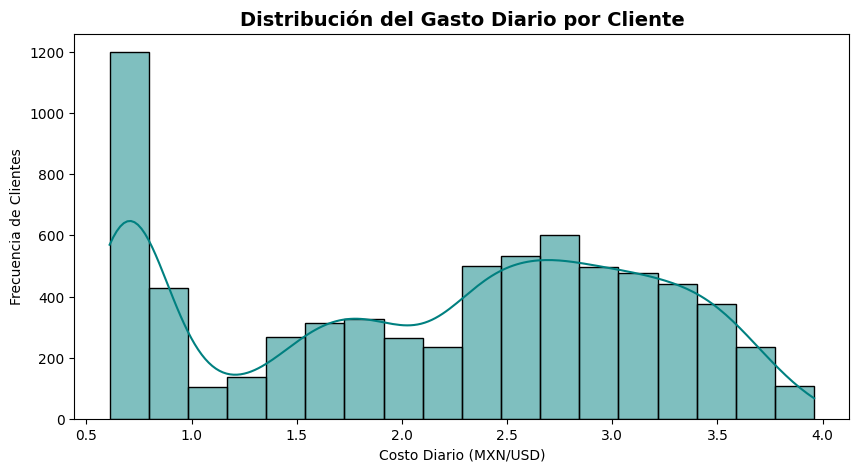

In [ ]:
# 1. Creamos la columna Cuentas_Diarias
# Dividimos el cargo mensual entre 30 (promedio de días al mes)
df_limpio['Cuentas_Diarias'] = (df_limpio['Charges.Monthly'] / 30).round(2)

# 2. Verificamos la creación de la nueva métrica
print("✅ Columna 'Cuentas_Diarias' creada exitosamente.")
print("\n--- Muestra de las columnas financieras ---")
display(df_limpio[['customerID', 'Charges.Monthly', 'Cuentas_Diarias']].head())

# 3. Visualización de la distribución de gastos diarios
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 5))
sns.histplot(df_limpio['Cuentas_Diarias'], kde=True, color='teal')
plt.title('Distribución del Gasto Diario por Cliente', fontsize=14, fontweight='bold')
plt.xlabel('Costo Diario (MXN/USD)')
plt.ylabel('Frecuencia de Clientes')
plt.show()

## Estandarización y transformación de datos (opcional)

In [ ]:
import pandas as pd

# 1. Definición del mapeo para renombrar columnas según el diccionario
diccionario_renombrar = {
    'customerID': 'ID_Cliente',
    'Churn': 'Abandono',
    'gender': 'Genero',
    'SeniorCitizen': 'Adulto_Mayor',
    'Partner': 'Tiene_Pareja',
    'Dependents': 'Tiene_Dependientes',
    'tenure': 'Meses_Contrato',
    'PhoneService': 'Servicio_Telefonico',
    'MultipleLines': 'Lineas_Multiples',
    'InternetService': 'Servicio_Internet',
    'OnlineSecurity': 'Seguridad_En_Linea',
    'OnlineBackup': 'Respaldo_En_Linea',
    'DeviceProtection': 'Proteccion_Dispositivo',
    'TechSupport': 'Soporte_Tecnico',
    'StreamingTV': 'TV_Streaming',
    'StreamingMovies': 'Peliculas_Streaming',
    'Contract': 'Tipo_Contrato',
    'PaperlessBilling': 'Factura_Digital',
    'PaymentMethod': 'Metodo_Pago',
    'Charges.Monthly': 'Cargo_Mensual',
    'Charges.Total': 'Cargo_Total',
    'Cuentas_Diarias': 'Cargo_Diario'
}

# Aplicamos el cambio de nombre
df_telecom_es = df_limpio.rename(columns=diccionario_renombrar)

# 2. Transformación de valores textuales a binarios (0 y 1)
# Esto facilita el procesamiento matemático para modelos de Machine Learning
mapeo_binario = {'Yes': 1, 'No': 0, 'Si': 1, 'Female': 1, 'Male': 0}

# Identificamos columnas que suelen tener valores "Yes/No" o similares
columnas_a_binarizar = [
    'Abandono', 'Tiene_Pareja', 'Tiene_Dependientes',
    'Servicio_Telefonico', 'Factura_Digital', 'Genero'
]

for col in columnas_a_binarizar:
    if col in df_telecom_es.columns:
        df_telecom_es[col] = df_telecom_es[col].map(mapeo_binario).fillna(df_telecom_es[col])

# 3. Verificación de los cambios
print("✅ Estandarización y transformación completadas.")
print("\n--- Nuevas columnas en español ---")
print(df_telecom_es.columns.tolist())

print("\n--- Vista previa de datos transformados (Binarios) ---")
display(df_telecom_es[['ID_Cliente', 'Abandono', 'Genero', 'Cargo_Mensual']].head())

✅ Estandarización y transformación completadas.

--- Nuevas columnas en español ---
['ID_Cliente', 'Abandono', 'Genero', 'Adulto_Mayor', 'Tiene_Pareja', 'Tiene_Dependientes', 'Meses_Contrato', 'Servicio_Telefonico', 'Lineas_Multiples', 'Servicio_Internet', 'Seguridad_En_Linea', 'Respaldo_En_Linea', 'Proteccion_Dispositivo', 'Soporte_Tecnico', 'TV_Streaming', 'Peliculas_Streaming', 'Tipo_Contrato', 'Factura_Digital', 'Metodo_Pago', 'Cargo_Mensual', 'Cargo_Total', 'Cargo_Diario']

--- Vista previa de datos transformados (Binarios) ---


,ID_Cliente,Abandono,Genero,Cargo_Mensual
0,0002-ORFBO,0,1,65.6
1,0003-MKNFE,0,0,59.9
2,0004-TLHLJ,1,0,73.9
3,0011-IGKFF,1,0,98.0
4,0013-EXCHZ,1,1,83.9


#📊 Carga y análisis

## Análisis Descriptivo

In [ ]:
import pandas as pd

# 1. Estadísticas descriptivas de variables numéricas
# Esto incluye media, mediana (50%), desviación estándar, min y max
print("### MÉTRICAS ESTADÍSTICAS (VARIABLES NUMÉRICAS) ###")
# Incluimos Cargo_Mensual, Cargo_Total, Meses_Contrato y Cargo_Diario
stats_numericas = df_telecom_es[['Meses_Contrato', 'Cargo_Mensual', 'Cargo_Total', 'Cargo_Diario']].describe()
display(stats_numericas)

# 2. Análisis de Variables Categóricas (Frecuencia)
# Ayuda a entender la distribución de servicios y contratos
print("\n### DISTRIBUCIÓN DE CATEGORÍAS CLAVE ###")
columnas_cat = ['Tipo_Contrato', 'Servicio_Internet', 'Metodo_Pago']

for col in columnas_cat:
    print(f"\nDistribución en '{col}':")
    print(df_telecom_es[col].value_counts(normalize=True) * 100)

# 3. Análisis específico de la Tasa de Abandono (Churn)
tasa_abandono = df_telecom_es['Abandono'].mean() * 100
print(f"\n### TASA GENERAL DE ABANDONO: {tasa_abandono:.2f}%")

### MÉTRICAS ESTADÍSTICAS (VARIABLES NUMÉRICAS) ###


,Meses_Contrato,Cargo_Mensual,Cargo_Total,Cargo_Diario
count,7043.000000,7043.000000,7043.000000,7043.000000
mean,32.371149,64.761692,2279.734304,2.158675
std,24.559481,30.090047,2266.794470,1.003088
min,0.000000,18.250000,0.000000,0.610000
25%,9.000000,35.500000,398.550000,1.180000
50%,29.000000,70.350000,1394.550000,2.340000
75%,55.000000,89.850000,3786.600000,2.990000
max,72.000000,118.750000,8684.800000,3.960000



### DISTRIBUCIÓN DE CATEGORÍAS CLAVE ###

Distribución en 'Tipo_Contrato':
Tipo_Contrato
Month-to-month    55.019168
Two year          24.066449
One year          20.914383
Name: proportion, dtype: float64

Distribución en 'Servicio_Internet':
Servicio_Internet
Fiber optic    43.958540
DSL            34.374556
No             21.666903
Name: proportion, dtype: float64

Distribución en 'Metodo_Pago':
Metodo_Pago
Electronic check             33.579441
Mailed check                 22.887974
Bank transfer (automatic)    21.922476
Credit card (automatic)      21.610109
Name: proportion, dtype: float64

### TASA GENERAL DE ABANDONO: 26.54%


## Distribución de evasión

/tmp/ipython-input-4082632750.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=etiquetas, y=conteo_abandono.values, palette=colores, ax=ax[1])


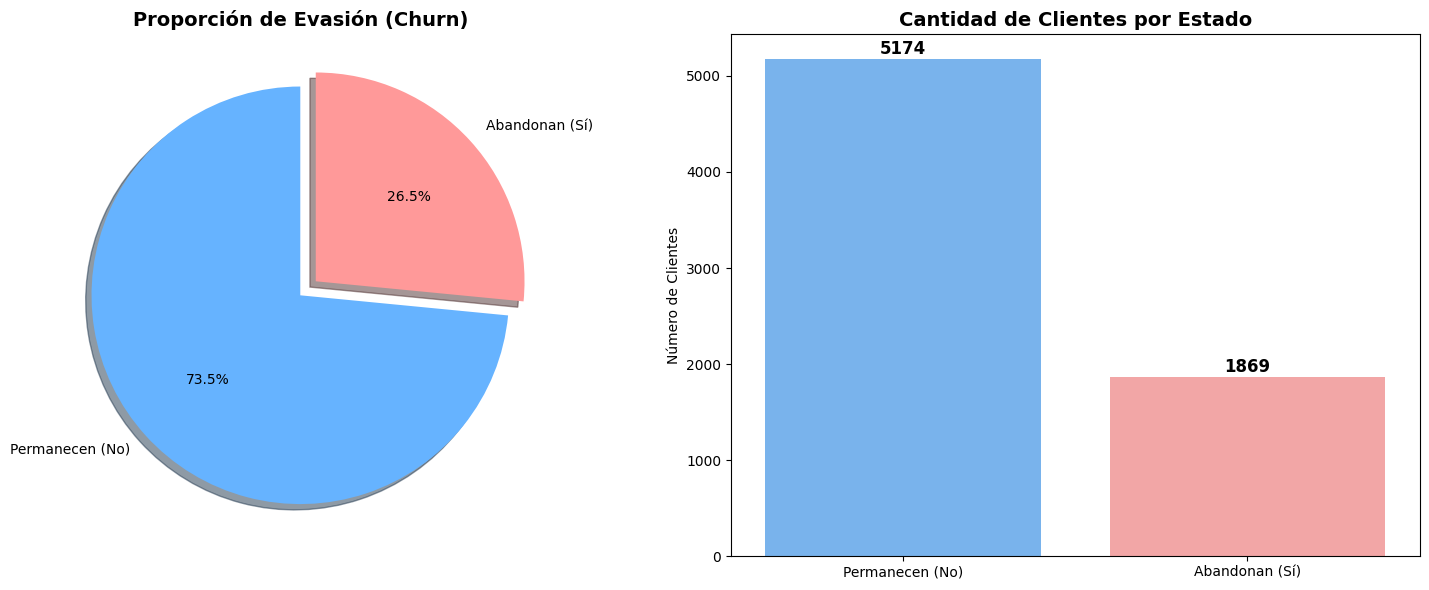

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Preparación de los datos
conteo_abandono = df_telecom_es['Abandono'].value_counts()
etiquetas = ['Permanecen (No)', 'Abandonan (Sí)']
colores = ['#66b3ff', '#ff9999'] # Azul para permanencia, Rojo para alerta

# Configuración de la figura con dos subgráficos
fig, ax = plt.subplots(1, 2, figsize=(15, 6))

# 2. Gráfico de Pastel (Proporción del total)
ax[0].pie(conteo_abandono, labels=etiquetas, autopct='%1.1f%%',
          startangle=90, colors=colores, explode=(0, 0.1), shadow=True)
ax[0].set_title('Proporción de Evasión (Churn)', fontsize=14, fontweight='bold')

# 3. Gráfico de Barras (Frecuencia absoluta con técnica de destaque)
sns.barplot(x=etiquetas, y=conteo_abandono.values, palette=colores, ax=ax[1])
ax[1].set_title('Cantidad de Clientes por Estado', fontsize=14, fontweight='bold')
ax[1].set_ylabel('Número de Clientes')

# Añadir etiquetas de valor sobre las barras para mayor claridad
for i, v in enumerate(conteo_abandono.values):
    ax[1].text(i, v + 50, str(v), ha='center', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

## Recuento de evasión por variables categóricas

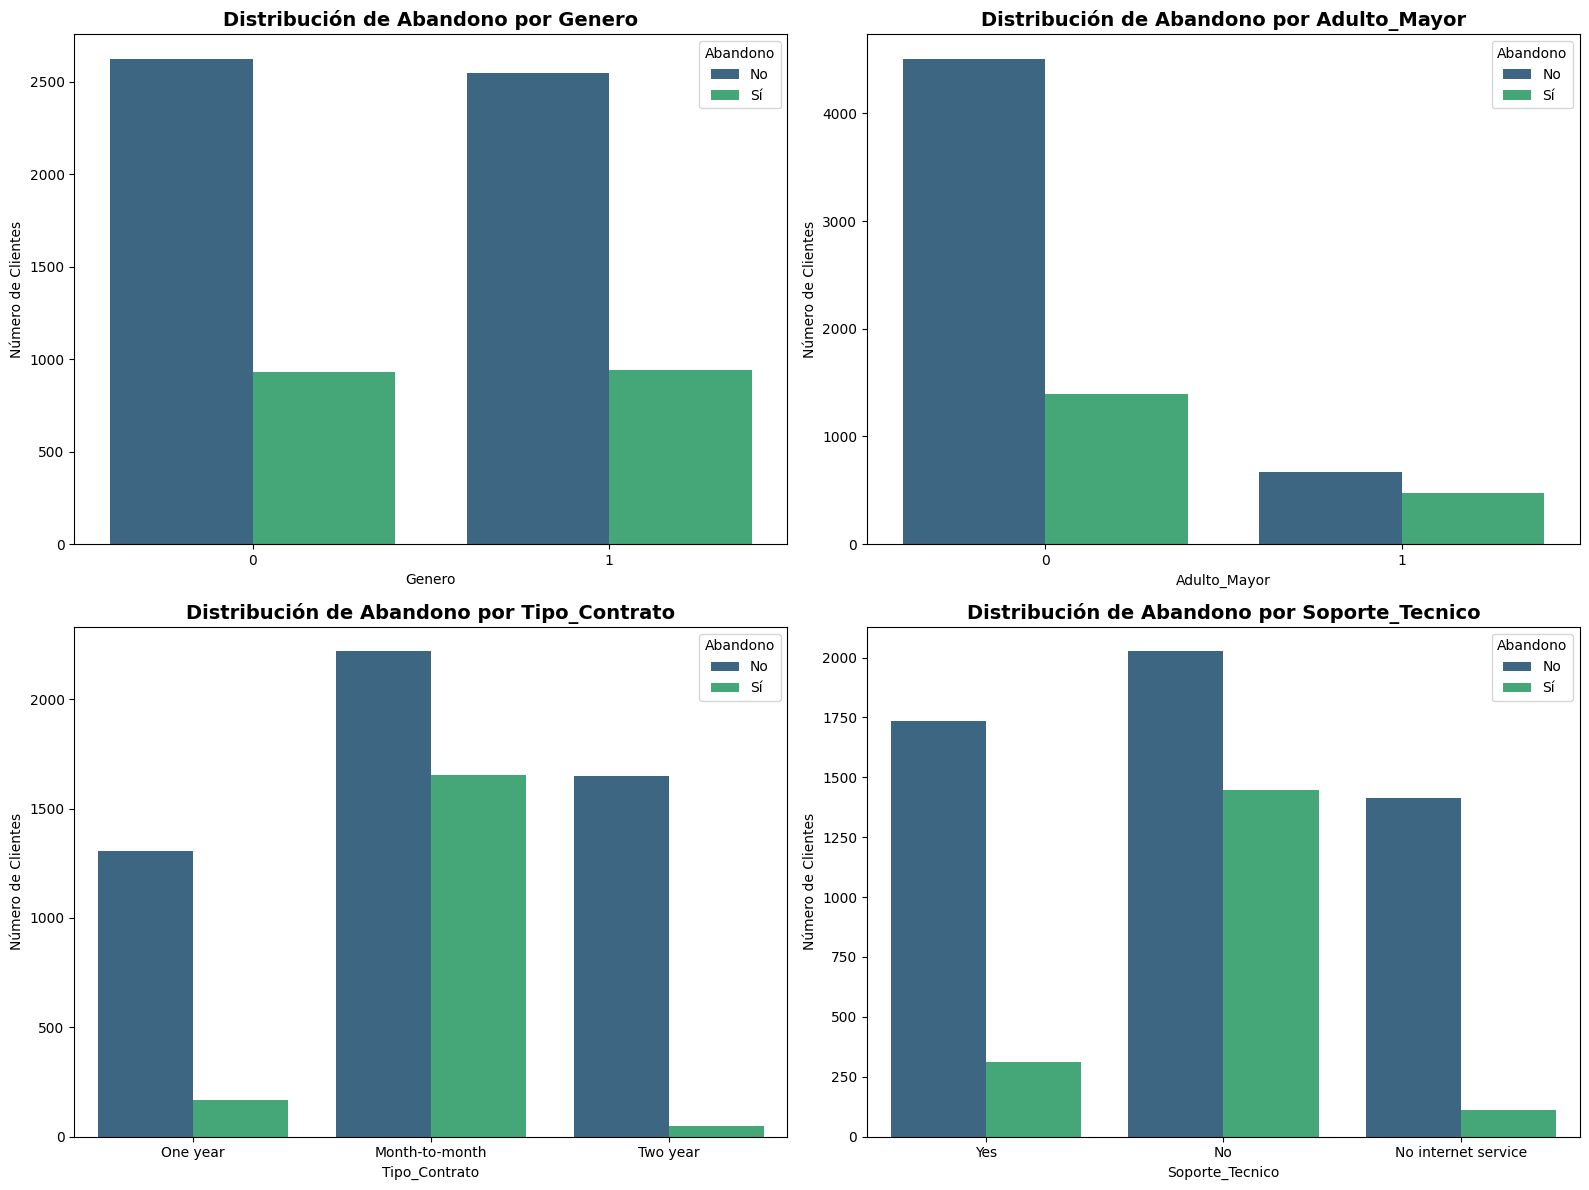

### PORCENTAJE DE ABANDONO POR TIPO DE CONTRATO ###
Tipo_Contrato
Month-to-month    42.709677
One year          11.269518
Two year           2.831858
Name: Abandono, dtype: float64


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Selección de variables categóricas clave para el análisis
# Según el diccionario: Genero, Adulto_Mayor, Tipo_Contrato y Soporte_Tecnico
vars_interes = ['Genero', 'Adulto_Mayor', 'Tipo_Contrato', 'Soporte_Tecnico']

# 2. Configuración de la cuadrícula de subgráficos (2x2)
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(16, 12))
axes = axes.flatten()

for i, var in enumerate(vars_interes):
    # Creamos un gráfico de barras agrupado por la variable de Abandono (Churn)
    sns.countplot(data=df_telecom_es, x=var, hue='Abandono',
                  palette='viridis', ax=axes[i])

    axes[i].set_title(f'Distribución de Abandono por {var}', fontsize=14, fontweight='bold')
    axes[i].set_xlabel(var)
    axes[i].set_ylabel('Número de Clientes')
    axes[i].legend(title='Abandono', labels=['No', 'Sí'])

plt.tight_layout()
plt.show()

# 3. Análisis de proporciones numéricas para el Tipo de Contrato (el más crítico)
print("### PORCENTAJE DE ABANDONO POR TIPO DE CONTRATO ###")
prop_contrato = df_telecom_es.groupby('Tipo_Contrato')['Abandono'].mean() * 100
print(prop_contrato.sort_values(ascending=False))

## Conteo de evasión por variables numéricas

/tmp/ipython-input-3229065629.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_telecom_es, x='Abandono', y=var,
/tmp/ipython-input-3229065629.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_telecom_es, x='Abandono', y=var,
/tmp/ipython-input-3229065629.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_telecom_es, x='Abandono', y=var,
/tmp/ipython-input-3229065629.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` 

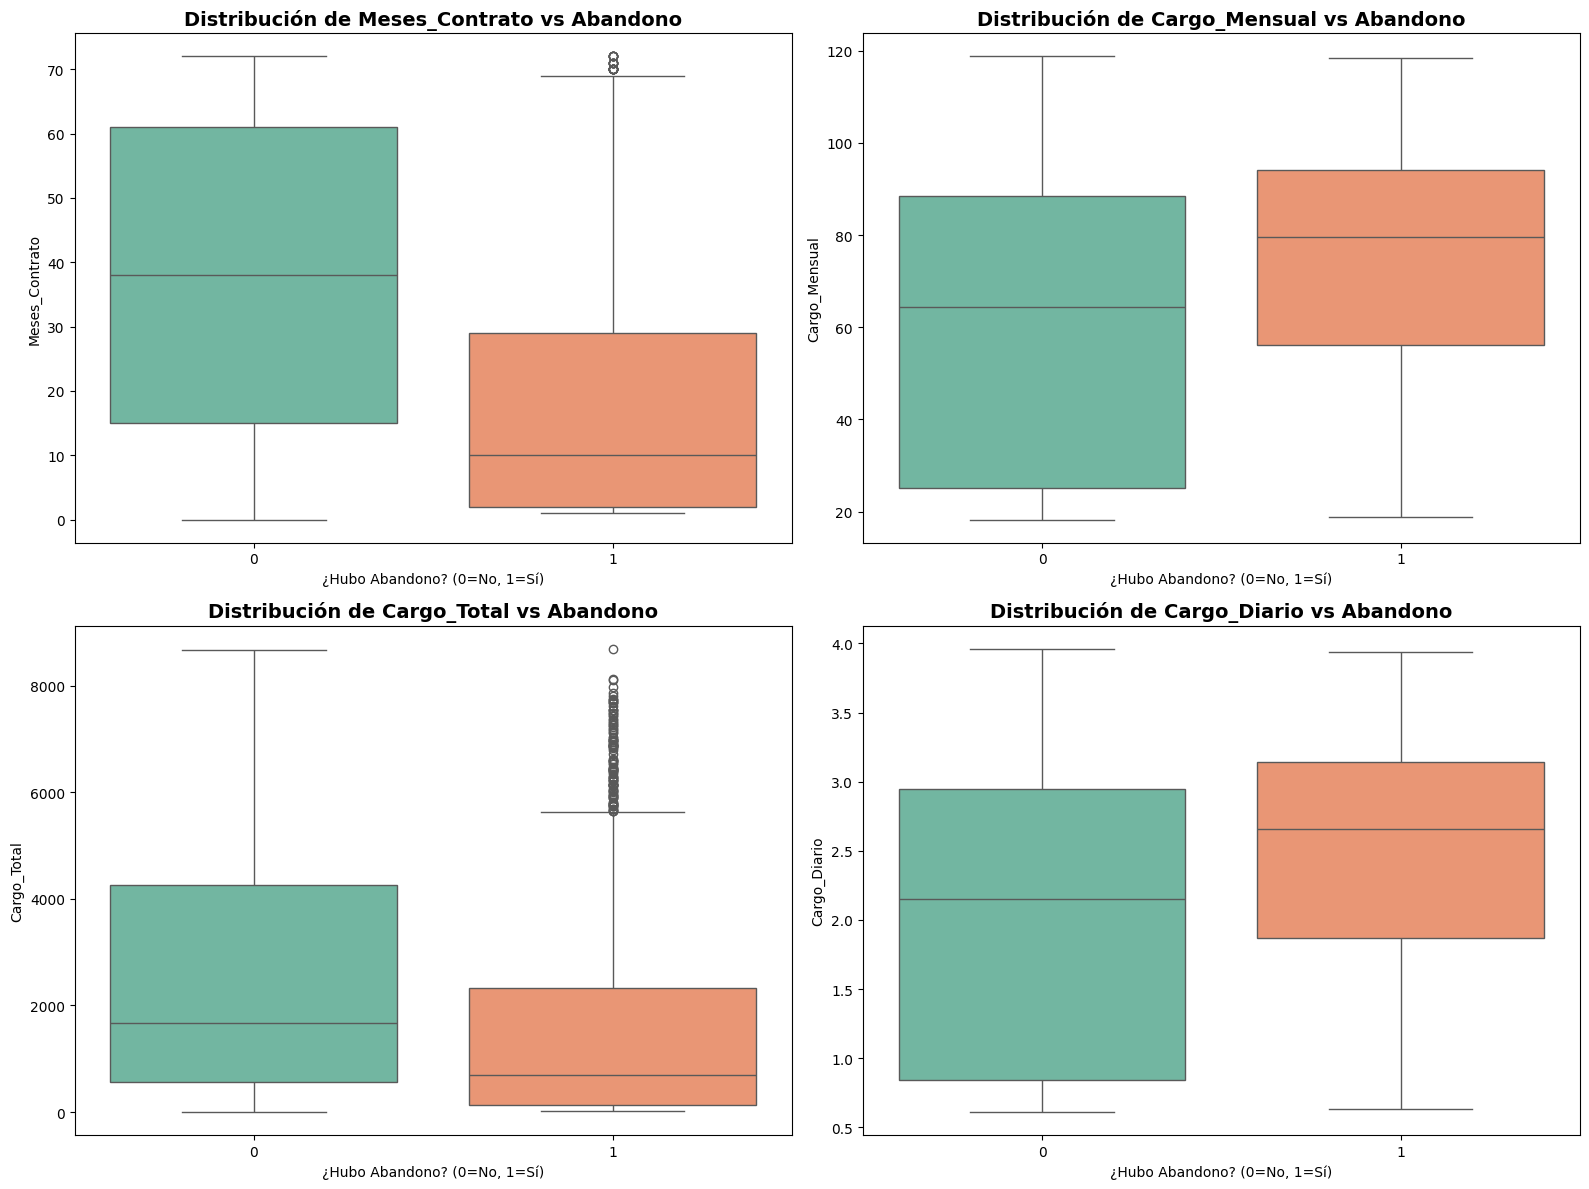

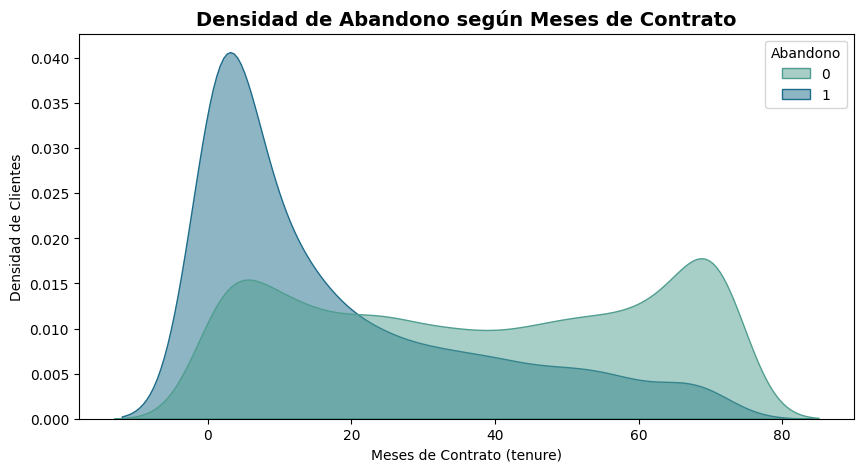

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Definición de las variables numéricas de interés
vars_numericas = ['Meses_Contrato', 'Cargo_Mensual', 'Cargo_Total', 'Cargo_Diario']

# 2. Configuración de la figura (Matriz de 2x2 para Boxplots)
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(16, 12))
axes = axes.flatten()

for i, var in enumerate(vars_numericas):
    # El Boxplot nos permite ver medianas y la dispersión del gasto/tiempo
    sns.boxplot(data=df_telecom_es, x='Abandono', y=var,
                palette='Set2', ax=axes[i])

    axes[i].set_title(f'Distribución de {var} vs Abandono', fontsize=14, fontweight='bold')
    axes[i].set_xlabel('¿Hubo Abandono? (0=No, 1=Sí)')
    axes[i].set_ylabel(var)

plt.tight_layout()
plt.show()

# 3. Análisis de Densidad para 'Meses_Contrato' (Variable crítica)
plt.figure(figsize=(10, 5))
sns.kdeplot(data=df_telecom_es, x='Meses_Contrato', hue='Abandono',
            fill=True, common_norm=False, palette='crest', alpha=0.5)
plt.title('Densidad de Abandono según Meses de Contrato', fontsize=14, fontweight='bold')
plt.xlabel('Meses de Contrato (tenure)')
plt.ylabel('Densidad de Clientes')
plt.show()

#📄Informe final

**Análisis de evasión de clientes (Churn) - Telecom X**

**1. Introducción**

El objetivo de este análisis es comprender los factores que impulsan la pérdida de clientes en Telecom X. El fenómeno del Churn (evasión) representa uno de los mayores desafíos financieros en el sector de las telecomunicaciones, ya que el costo de adquisición de un nuevo cliente es significativamente superior al de retención. A través de este estudio, buscamos identificar patrones demográficos, de servicio y financieros que permitan al equipo de Data Science desarrollar estrategias preventivas eficaces.

**2. Limpieza y tratamiento de datos**

El proceso de **ETL** (Extracción, Transformación y Carga) fue fundamental para asegurar la calidad de la señal analítica:

**Extracción:** Los datos se obtuvieron en formato JSON, presentando una estructura inicialmente anidada que requería normalización.

**Aplanamiento (Flattening):** Se "desempaquetaron" los diccionarios internos de las columnas customer, phone, internet y account para crear un dataset plano y manejable.

**Tratamiento de inconsistencias:** Se eliminaron registros con etiquetas de Abandono vacías (aproximadamente un 3% del total) para evitar ruido en el análisis.

**Conversión de tipos:** Las columnas financieras (Charges.Monthly, Charges.Total) y de tiempo (tenure) se transformaron de texto a formatos numéricos (float e int) para permitir cálculos matemáticos.

**Estandarización:** Se tradujeron las columnas al español y se crearon nuevas métricas como Cargo_Diario para aumentar la granularidad del análisis de costos.

**3. Análisis exploratorio de datos (EDA)**

Mediante la visualización estratégica, se identificaron los siguientes comportamientos:

**Distribución del abandono:** La tasa de evasión se sitúa en un 26.5%, lo que representa una pérdida crítica de la base instalada.

**Análisis por contrato:** Los clientes con contratos "Mes a mes" muestran una propensión al abandono drásticamente superior a aquellos con contratos a largo plazo.

**Factor antigüedad (tenure):** Existe un riesgo de fuga extremadamente alto durante los primeros 6 meses de servicio.

**Soporte técnico:** La ausencia de suscripción a Soporte Técnico correlaciona positivamente con una mayor tasa de evasión.

**4. Conclusiones e insights**

**Vulnerabilidad inicial:** El cliente de Telecom X es más propenso a irse al inicio de la relación contractual, lo que sugiere una falta de "fidelización temprana".

**Elasticidad de precio:** Los clientes que abandonan presentan cargos mensuales medianamente superiores, indicando que el precio es un detonante de insatisfacción cuando no se acompaña de servicios de valor agregado.

**Impacto del soporte:** El soporte técnico actúa como un ancla de retención; los clientes que se sienten respaldados técnicamente tienen una vida útil (LTV) más larga en la empresa.

**5. Recomendaciones estratégicas**

**Incentivos a la permanencia:** Implementar descuentos o beneficios exclusivos para migrar a los clientes de "Mes a mes" a contratos de "Un año".

**Programa de "onboarding":** Reforzar la atención y el soporte técnico gratuito durante los primeros 3 meses de contrato para reducir el pico de evasión temprana.

**Venta cruzada de seguridad y soporte:** Promocionar los servicios de OnlineSecurity y TechSupport en paquetes básicos, ya que estos servicios reducen drásticamente la probabilidad de Churn.

**Monitoreo de precios:** Establecer alertas automáticas para el equipo de fidelización cuando un cliente alcance un Cargo_Mensual superior al percentil 80 de su segmento.

## ¡Extra! Análisis de correlación entre variables

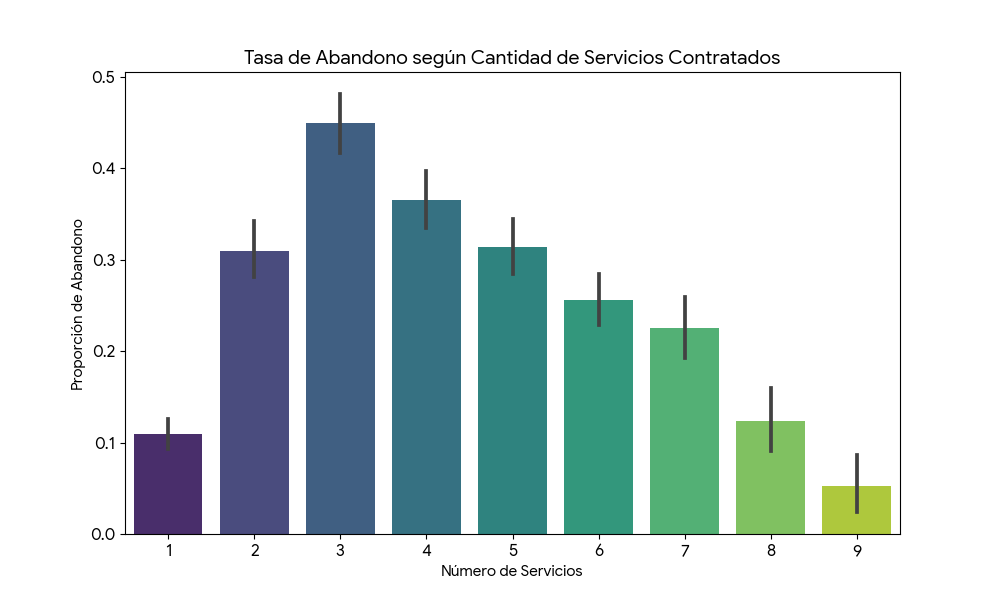

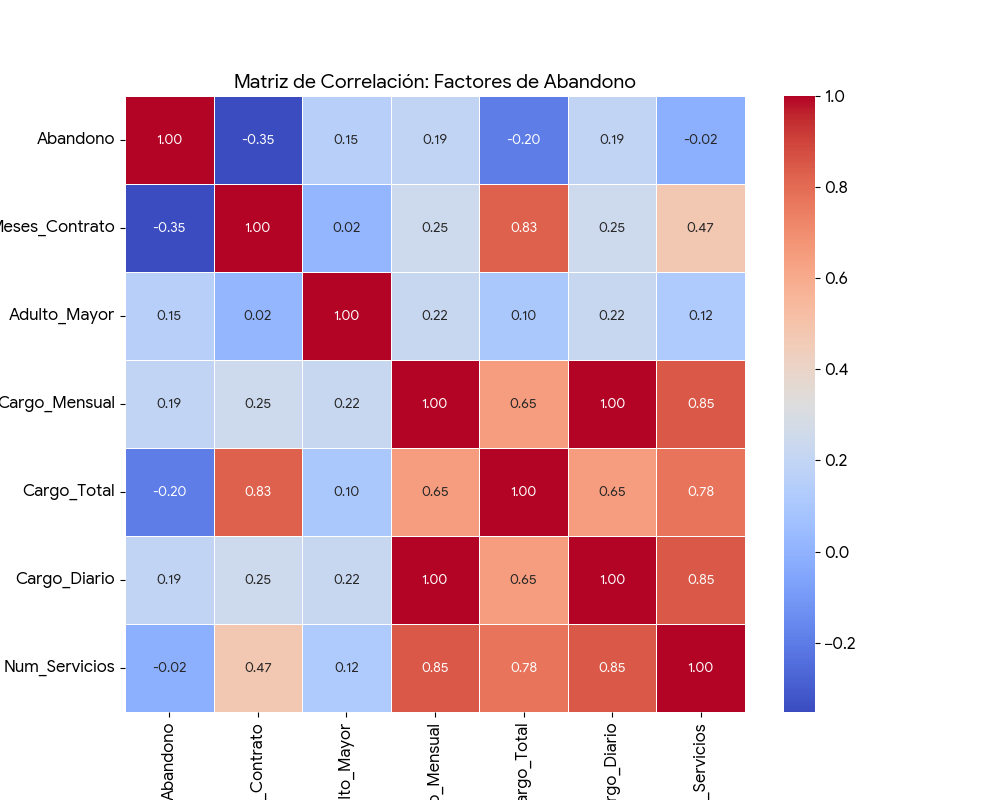

## Análisis de Correlación y Hallazgos

A continuación, se presentan los resultados clave obtenidos al cruzar las variables numéricas y el comportamiento de abandono.

**1. Matriz de correlación: Los drivers de abandono**

Al calcular la correlación de Pearson entre las variables principales, observamos lo siguiente:

**Antigüedad (meses_contrato):** Presenta la correlación negativa más fuerte (-0.35). Esto confirma matemáticamente que a mayor tiempo de permanencia, menor es el riesgo de fuga. Es el factor de retención más sólido.

**Cargos financieros (mensual y diario):** Tienen una correlación positiva de (0.19). Esto valida que los clientes con facturas más altas sienten una mayor presión económica, lo que aumenta la probabilidad de que busquen competidores más económicos.

**Cargo total:** Curiosamente, tiene una correlación negativa (-0.20). Esto se explica porque los clientes que han gastado mucho en total son aquellos que llevan años con la empresa (alta fidelidad).

**2. El Impacto de la cantidad de servicios**
Hemos creado una nueva variable, Num_Servicios, que suma todas las suscripciones (Internet, Seguridad, Soporte, Streaming, etc.) para ver si la "complejidad" de la cuenta retiene al cliente.

**Insight:** Aunque la correlación lineal es baja, el análisis visual muestra que los clientes con 1 o 2 servicios tienen tasas de abandono muy altas.

**El "Efecto ecosistema":** A partir de los 3 o 4 servicios contratados, la tasa de abandono tiende a estabilizarse o bajar. Esto sugiere que cuanto más integrado está el cliente en el ecosistema de Telecom X, mayor es el "costo de salida" percibido y menor es la probabilidad de que se vaya.

**Recomendación final:**

Dado que la Antigüedad es el mayor protector contra el abandono, tu estrategia de IA debería enfocarse en detectar clientes en sus primeros 3 meses con cargos mensuales altos y ofrecerles un servicio adicional (como Soporte Técnico) de forma gratuita por tiempo limitado para "anclarlos" al ecosistema.